# Etna Dataset

This notebook builds the Etna case-study dataset for the Cause–Trigger analysis. Waveform features are extracted on an hourly grid, then merged with gas and meteorological context variables. The final dataset is used later for HMML/PCMCI-based trigger analysis.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from obspy.clients.fdsn import Client

PROJECT_ROOT = Path.cwd().parent
SRC_DIR = PROJECT_ROOT / "src/etna"
sys.path.append(str(SRC_DIR))

from etna_config import (
    ETNA_WAVEFORM_CONFIG,
    ETNA_GAS_METEO_COLS,
    ETNA_EVENT_TIME,
    ETNA_WEATHER_COLS,
)

from etna_waveform import build_station_waveform_dataset

from etna_dataset import (
    load_etnagas_csv,
    extract_plume_co2so2_xls,
    create_etna_final_dataset,
    load_openmeteo_etna_weather,
)

from etna_plotting_utils import (
    dataset_health_report,
    plot_scaled_dataset,
    plot_variable_pdfs,
    distribution_summary,
    run_teleseismic_checks,
    plot_etna_data_with_event,
)

from etna_geo_metadata import etna_observable_metadata
from etna_geo_plotting import plot_etna_all_variables_map

from etna_stations import (
    run_station_screening,
    export_station_screening_results,
)

client = Client("INGV")
cfg = ETNA_WAVEFORM_CONFIG
ETNA_STATION = ETNA_WAVEFORM_CONFIG["stations"][0]

import warnings
from obspy.io.mseed import InternalMSEEDWarning

warnings.filterwarnings(
    "ignore",
    category=InternalMSEEDWarning,
    message=r".*fractional second.*10000.*",
)
warnings.filterwarnings(
    "ignore",
    message=r".*fractional seconds.*10000.*",
)


## Etna station availability screening for full analysis window

This section identifies the best Etna seismic station(s) for the full analysis window without downloading the full waveform archive. It first discovers all available vertical channels, then probes a short waveform segment on each day of the study period. Stations are ranked by daily availability and distance to the Etna summit.

Keep `RUN_STATION_SCREENING = False` for normal dataset construction. Set it to `True` only if you want to rerun the reproducible station-selection check and export fresh CSV/TXT reports.


In [2]:
RUN_STATION_SCREENING = False  # Set to True to run station screening, False to skip and use selected station from config

if RUN_STATION_SCREENING:
    streams_found, daily_probe, station_summary = run_station_screening(
        client=client,
        waveform_cfg=ETNA_WAVEFORM_CONFIG,
        max_distance_km=80.0,
        probe_offset_hours=12,
        probe_duration_minutes=10,
        verbose=True,
        display_func=display,
    )

    export_paths = export_station_screening_results(
        station_summary=station_summary,
        daily_probe=daily_probe,
        out_dir="etna_stations",
        waveform_cfg=ETNA_WAVEFORM_CONFIG,
        probe_offset_hours=12,
        probe_duration_minutes=10,
    )

    print("\nRanked station-channel candidates:")
    display(station_summary)

    print("\nBest complete candidates:")
    display(station_summary.query("ok_fraction == 1.0"))

    print("\nSaved station-screening files:")
    for name, path in export_paths.items():
        print(f"{name}: {path}")
else:
    print(
        "Station screening skipped. "
        "Using selected station from ETNA_WAVEFORM_CONFIG: "
        f"{ETNA_STATION}.{ETNA_WAVEFORM_CONFIG['location']}.{ETNA_WAVEFORM_CONFIG['channel']}"
    )

c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\obspy\core\inventory\util.py:1123: UserWarning: Given string seems to not be a valid URI: '78'
  warnings.warn(msg)
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\obspy\core\inventory\util.py:1123: UserWarning: Given string seems to not be a valid URI: '246'
  warnings.warn(msg)
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\obspy\core\inventory\util.py:1123: UserWarning: Given string seems to not be a valid URI: '267'
  warnings.warn(msg)
c:\Users\cescedes\anaconda3\envs\M\Lib\site-packages\obspy\core\inventory\util.py:1123: UserWarning: Given string seems to not be a valid URI: '342'
  warnings.warn(msg)


Discovered 565 vertical stream(s) before distance filtering.
Keeping 64 vertical stream(s) within 80 km of Etna summit.


,network,station,location,channel,metadata_start,metadata_end,metadata_start_date,metadata_end_date,lat,lon,elevation_m,distance_km
0,IV,ESLN,,BHZ,2005-07-10T00:00:00.000000Z,None,2005-07-10,open/unknown,37.6934,14.9744,1787.0,6.445278
1,IV,ESLN,,HHZ,2005-07-10T00:00:00.000000Z,None,2005-07-10,open/unknown,37.6934,14.9744,1787.0,6.445278
2,IV,ESLN,,LHZ,2005-07-10T00:00:00.000000Z,None,2005-07-10,open/unknown,37.6934,14.9744,1787.0,6.445278
3,IV,ESLN,,VHZ,2005-07-10T00:00:00.000000Z,None,2005-07-10,open/unknown,37.6934,14.9744,1787.0,6.445278
4,IV,ECTS,,HHZ,2007-07-18T12:00:00.000000Z,2019-12-23T11:00:00.000000Z,2007-07-18,2019-12-23,37.8825,15.1212,644.0,18.409270
...,...,...,...,...,...,...,...,...,...,...,...,...
59,IV,MRCB,01,HHZ,2007-11-08T00:00:00.000000Z,2009-06-10T23:00:00.000000Z,2007-11-08,2009-06-10,38.1620,15.7030,500.0,77.000102
60,IV,ILOS,,BHZ,2005-05-11T00:00:00.000000Z,2023-10-20T10:00:00.000000Z,2005-05-11,2023-10-20,38.4457,14.9483,283.0,77.707450
61,IV,ILOS,,HHZ,2005-05-11T00:00:00.000000Z,2023-10-20T10:00:00.000000Z,2005-05-11,2023-10-20,38.4457,14.9483,283.0,77.707450
62,IV,ILOS,,LHZ,2005-05-11T00:00:00.000000Z,2023-10-20T10:00:00.000000Z,2005-05-11,2023-10-20,38.4457,14.9483,283.0,77.707450


[1/64] IV.ESLN..BHZ | distance=6.4 km | metadata period=2005-07-10 to open/unknown
[2/64] IV.ESLN..HHZ | distance=6.4 km | metadata period=2005-07-10 to open/unknown
[3/64] IV.ESLN..LHZ | distance=6.4 km | metadata period=2005-07-10 to open/unknown
[4/64] IV.ESLN..VHZ | distance=6.4 km | metadata period=2005-07-10 to open/unknown
[5/64] IV.ECTS..HHZ | distance=18.4 km | metadata period=2007-07-18 to 2019-12-23
[6/64] IV.GIO..SHZ | distance=22.3 km | metadata period=2007-12-04 to 2013-03-13
[7/64] IV.ECNV..BHZ | distance=30.4 km | metadata period=2007-01-30 to 2017-09-09
[8/64] IV.ECNV..HHZ | distance=30.4 km | metadata period=2007-01-30 to 2017-09-09
[9/64] IV.ECNV..LHZ | distance=30.4 km | metadata period=2007-01-30 to 2017-09-09
[10/64] IV.ECNV..VHZ | distance=30.4 km | metadata period=2007-01-30 to 2017-09-09
[11/64] IV.MMME..BHZ | distance=30.6 km | metadata period=2004-07-12 to 2012-05-16
[12/64] IV.MMME..HHZ | distance=30.6 km | metadata period=2004-07-12 to 2012-05-16
[13/64] IV

,network,station,location,channel,lat,lon,distance_km,metadata_start_date,metadata_end_date,n_days,...,actual_data_end,actual_data_start_date,actual_data_end_date,actual_data_ranges,missing_dates,mean_probe_coverage,min_probe_coverage,n_error_days,sample_rates,channel_rank
0,IV,ESLN,,HHZ,37.6934,14.9744,6.445278,2005-07-10,open/unknown,32,...,2008-05-13,2008-04-12,2008-05-13,2008-04-12 to 2008-05-13,,1.000000,1.000000,0,100.0,1
1,IV,ESLN,,BHZ,37.6934,14.9744,6.445278,2005-07-10,open/unknown,32,...,2008-05-13,2008-04-12,2008-05-13,2008-04-12 to 2008-05-13,,0.999990,0.999917,0,20.0,2
2,IV,ESLN,,LHZ,37.6934,14.9744,6.445278,2005-07-10,open/unknown,32,...,2008-05-13,2008-04-12,2008-05-13,2008-04-12 to 2008-05-13,,1.000000,1.000000,0,1.0,5
3,IV,ESLN,,VHZ,37.6934,14.9744,6.445278,2005-07-10,open/unknown,32,...,2008-05-13,2008-04-12,2008-05-13,2008-04-12 to 2008-05-13,,1.000000,1.000000,0,0.1,6
4,IV,ECTS,,HHZ,37.8825,15.1212,18.409270,2007-07-18,2019-12-23,32,...,2008-05-13,2008-04-12,2008-05-13,2008-04-12 to 2008-05-13,,0.994273,0.816733,0,100.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,IV,MILZ,,VHZ,38.2713,15.2313,61.644775,2008-02-26,open/unknown,32,...,NaT,none/open,none/open,,"2008-04-12, 2008-04-13, 2008-04-14, 2008-04-15...",0.000000,0.000000,32,,6
60,IV,IVUG,,HHZ,38.3960,14.9860,72.063298,2007-04-13,open/unknown,32,...,NaT,none/open,none/open,,"2008-04-12, 2008-04-13, 2008-04-14, 2008-04-15...",0.000000,0.000000,32,,1
61,IV,IVUG,,BHZ,38.3960,14.9860,72.063298,2007-04-13,open/unknown,32,...,NaT,none/open,none/open,,"2008-04-12, 2008-04-13, 2008-04-14, 2008-04-15...",0.000000,0.000000,32,,2
62,IV,IVUG,,LHZ,38.3960,14.9860,72.063298,2007-04-13,open/unknown,32,...,NaT,none/open,none/open,,"2008-04-12, 2008-04-13, 2008-04-14, 2008-04-15...",0.000000,0.000000,32,,5



Best complete candidates:


,network,station,location,channel,lat,lon,distance_km,metadata_start_date,metadata_end_date,n_days,...,actual_data_end,actual_data_start_date,actual_data_end_date,actual_data_ranges,missing_dates,mean_probe_coverage,min_probe_coverage,n_error_days,sample_rates,channel_rank
0,IV,ESLN,,HHZ,37.693400,14.974400,6.445278,2005-07-10,open/unknown,32,...,2008-05-13,2008-04-12,2008-05-13,2008-04-12 to 2008-05-13,,1.000000,1.000000,0,100.0,1
1,IV,ESLN,,BHZ,37.693400,14.974400,6.445278,2005-07-10,open/unknown,32,...,2008-05-13,2008-04-12,2008-05-13,2008-04-12 to 2008-05-13,,0.999990,0.999917,0,20.0,2
2,IV,ESLN,,LHZ,37.693400,14.974400,6.445278,2005-07-10,open/unknown,32,...,2008-05-13,2008-04-12,2008-05-13,2008-04-12 to 2008-05-13,,1.000000,1.000000,0,1.0,5
3,IV,ESLN,,VHZ,37.693400,14.974400,6.445278,2005-07-10,open/unknown,32,...,2008-05-13,2008-04-12,2008-05-13,2008-04-12 to 2008-05-13,,1.000000,1.000000,0,0.1,6
4,IV,ECTS,,HHZ,37.882500,15.121200,18.409270,2007-07-18,2019-12-23,32,...,2008-05-13,2008-04-12,2008-05-13,2008-04-12 to 2008-05-13,,0.994273,0.816733,0,100.0,1
5,IV,GIO,,SHZ,37.566670,15.108330,22.342209,2007-12-04,2013-03-13,32,...,2008-05-13,2008-04-12,2008-05-13,2008-04-12 to 2008-05-13,,0.997496,0.959967,0,50.0,4
6,IV,MNO,,SHZ,37.931000,14.695000,33.566607,2007-12-17,2019-11-27,32,...,2008-05-13,2008-04-12,2008-05-13,2008-04-12 to 2008-05-13,,1.033042,0.949867,0,50.0,4
7,IV,MALI,01,EHZ,38.053000,15.400000,48.868387,2007-10-20,2009-04-23,32,...,2008-05-13,2008-04-12,2008-05-13,2008-04-12 to 2008-05-13,,1.000000,1.000000,0,125.0,3
8,IV,HAGA,,HHZ,37.285800,15.155200,53.208633,2005-02-17,2022-05-16,32,...,2008-05-13,2008-04-12,2008-05-13,2008-04-12 to 2008-05-13,,1.000000,1.000000,0,100.0,1
9,IV,AGST,,EHZ,37.256520,15.227130,58.237549,2004-05-24,2012-08-13,32,...,2008-05-13,2008-04-12,2008-05-13,2008-04-12 to 2008-05-13,,1.000000,1.000000,0,50.0,3



Saved station-screening files:
summary_csv: etna_stations\etna_station_screening_summary.csv
daily_csv: etna_stations\etna_station_screening_daily_probe.csv
best_csv: etna_stations\etna_station_screening_best_complete_candidates.csv
report_txt: etna_stations\etna_station_screening_report.txt


## 1. Selected station and channel metadata

We inspect the selected ESLN HHZ stream metadata. ESLN was selected because it is close to the Etna summit, has complete retrievable data over the full analysis window, and clearly records the Wenchuan wave arrival.


In [4]:
inventory = client.get_stations(
    network=ETNA_WAVEFORM_CONFIG["network"],
    station=ETNA_STATION,
    location=ETNA_WAVEFORM_CONFIG["location"],
    channel=ETNA_WAVEFORM_CONFIG["channel"],
    level="response",
    starttime=ETNA_WAVEFORM_CONFIG["start"],
    endtime=ETNA_WAVEFORM_CONFIG["end"],
)

print(inventory)

Inventory created at 2026-06-07T22:01:02.620000Z
	Created by: INGV-ONT WEB SERVICE: fdsnws-station | version: 1.1.64
		    /exist/apps/fdsn-station/fdsnws/station/1/query?starttime=2008-04-...
	Sending institution: eXistDB (INGV-ONT)
	Contains:
		Networks (1):
			IV
		Stations (1):
			IV.ESLN (Serra La Nave)
		Channels (1):
			IV.ESLN..HHZ


## 2. Hourly waveform feature extraction

Waveform data are processed in daily chunks with padding for filter stability. Three log-transformed RMS features are extracted on the hourly grid:

- `teleseismic`: low-frequency teleseismic trigger proxy, 0.03–0.30 Hz, aggregated by hourly maximum.
- `background_seismic`: Etna tremor/state proxy, 0.80–2.30 Hz, aggregated by hourly mean.
- `effect_seismic`: higher-frequency local response/effect proxy, 4–8 Hz, aggregated by hourly maximum.


In [ ]:
REDOWNLOAD = False  # set True to force redownloading and reprocessing, False to use cached dataset

esln_wave, esln_failures = build_station_waveform_dataset(
    client=client,
    station=ETNA_STATION,
    cfg=cfg,
    cache_path="../data/etna/etna_esln_hhz_waveform.pkl",
    redownload=REDOWNLOAD,
)

print("failures:", esln_failures)
print("shape:", esln_wave.shape)
display(esln_wave.head())
display(esln_wave.tail())
display(esln_wave.isna().mean())

ESLN OK  2008-04-12
ESLN OK  2008-04-13
ESLN OK  2008-04-14
ESLN OK  2008-04-15
ESLN OK  2008-04-16
ESLN OK  2008-04-17
ESLN OK  2008-04-18
ESLN OK  2008-04-19
ESLN OK  2008-04-20
ESLN OK  2008-04-21
ESLN OK  2008-04-22
ESLN OK  2008-04-23
ESLN OK  2008-04-24
ESLN OK  2008-04-25
ESLN OK  2008-04-26
ESLN OK  2008-04-27
ESLN OK  2008-04-28
ESLN OK  2008-04-29
ESLN OK  2008-04-30
ESLN OK  2008-05-01
ESLN OK  2008-05-02
ESLN OK  2008-05-03
ESLN OK  2008-05-04
ESLN OK  2008-05-05
ESLN OK  2008-05-06
ESLN OK  2008-05-07
ESLN OK  2008-05-08
ESLN OK  2008-05-09
ESLN OK  2008-05-10
ESLN OK  2008-05-11
ESLN OK  2008-05-12
ESLN OK  2008-05-13
ESLN: saved waveform features to ..\data\etna\etna_esln_hhz_waveform.pkl
failures: []
shape: (768, 3)


,background_seismic,teleseismic,effect_seismic
time,,,
2008-04-12 00:00:00+00:00,8.661510e-07,1.256454e-05,2.638814e-07
2008-04-12 01:00:00+00:00,9.140667e-07,4.973265e-06,3.410711e-07
2008-04-12 02:00:00+00:00,8.189398e-07,9.794768e-06,2.473225e-07
2008-04-12 03:00:00+00:00,8.954102e-07,8.487834e-07,2.458478e-07
2008-04-12 04:00:00+00:00,7.463208e-07,1.288918e-05,2.968856e-07


,background_seismic,teleseismic,effect_seismic
time,,,
2008-05-13 19:00:00+00:00,0.000009,3.589814e-07,0.000002
2008-05-13 20:00:00+00:00,0.000009,3.789607e-07,0.000003
2008-05-13 21:00:00+00:00,0.009653,4.470074e-01,0.058749
2008-05-13 22:00:00+00:00,0.006616,4.248718e-01,0.048107
2008-05-13 23:00:00+00:00,0.000006,4.742199e-07,0.000002


background_seismic    0.0
teleseismic           0.0
effect_seismic        0.0
dtype: float64

## 3. Gas and meteorological variables

These variables are merged onto the hourly waveform grid:

- WindSpeed [1] 
- AirTemp_3 [1] 
- CO2_3 [1] 
- pressure_drop (derived from Patm_3 column) [1]
- plume data (SO2/CO2 ratio) [2]
- Antecedent Precipitation Index (API) (derived from Open-Meteo rainfall data) [3]

[1] Liuzzo, M., Giuffrida, G. B., & Gurrieri, S. (2025). Etna CO2 Soil Flux during 2002-2010 (ECSF2002_2010) [Data set]. Istituto Nazionale di Geofisica e Vulcanologia (INGV). https://doi.org/10.13127/etna/ecsf2002_2010

[2] Aiuppa A., Giudice G., Liuzzo M. (2017). Volcanic gas plume data from Etna Volcano (Italy) (Version 1.0) [Data set]. Interdisciplinary Earth Data Alliance (IEDA). https://doi.org/10.1594/ieda/1006438

[3] Zippenfenig, P. (2023). Open-Meteo.com Weather API [Computer software]. Zenodo. https://doi.org/10.5281/ZENODO.7970649


In [6]:
plume_df = extract_plume_co2so2_xls("../data/etna/1012-1_VolcanicGas_Etna.xls")

In [7]:
etnagas_df = load_etnagas_csv(
    path="../data/etna/3c.csv",
    value_cols=ETNA_GAS_METEO_COLS,
)

display(etnagas_df.head())
display(etnagas_df.isna().mean().sort_values())

,timestamp,CO2_3,AirTemp_3,pressure_drop,WindSpeed
0,2008-01-18 00:00:00+00:00,0.283836,NaN,0.0,0.0
1,2008-01-18 01:00:00+00:00,0.287348,NaN,0.0,0.0
2,2008-01-18 02:00:00+00:00,0.274303,NaN,0.0,0.0
3,2008-01-18 03:00:00+00:00,0.269285,NaN,0.0,0.0
4,2008-01-18 04:00:00+00:00,0.265773,NaN,0.0,0.0


timestamp        0.000000
pressure_drop    0.000000
WindSpeed        0.000039
CO2_3            0.002269
AirTemp_3        0.012401
dtype: float64

In [8]:
etna_weather_df = load_openmeteo_etna_weather(
    start_date="2008-04-12",
    end_date="2008-05-14",
)

## 4. Merge, scale, and save final hourly datasets

The waveform, gas, meteorological, and plume variables are merged by timestamp. Raw variables are retained, and scaled versions are produced for causal discovery. 

In [9]:
final_esln_raw, final_esln_scaled = create_etna_final_dataset(
    wave_df=esln_wave,
    station_name=ETNA_STATION,
    out_csv="../data/etna/FINAL_ESLN.csv",
    etnagas_df=etnagas_df,
    etnagas_cols=ETNA_GAS_METEO_COLS,
    plume_df=plume_df,
    weather_df=etna_weather_df,
    weather_cols=ETNA_WEATHER_COLS,
)


Saved: ../data/etna/FINAL_ESLN_raw.csv
Saved: ../data/etna/FINAL_ESLN_scaled.csv


## 5. Dataset checks

We check dataset size, timestamp order, duplicate timestamps, missing values, and variable distributions. These checks ensure that the final hourly dataset is suitable for causal discovery.

In [10]:
station_data = {
    ETNA_STATION: {
        "wave": esln_wave,
        "final_raw": final_esln_raw,
        "final_scaled": final_esln_scaled,
    },
}


In [11]:
for sta, d in station_data.items():
    dataset_health_report(d["final_raw"], f"{sta} hourly raw")
    dataset_health_report(d["final_scaled"], f"{sta} hourly scaled")


ESLN hourly raw
shape: (768, 11)
duplicate timestamps: 0
time sorted: True

Missing fraction:
station               0.0
time                  0.0
teleseismic           0.0
background_seismic    0.0
effect_seismic        0.0
CO2_3                 0.0
AirTemp_3             0.0
pressure_drop         0.0
WindSpeed             0.0
API                   0.0
CO2_SO2               0.0
dtype: float64

ESLN hourly scaled
shape: (768, 11)
duplicate timestamps: 0
time sorted: True

Missing fraction:
time                         0.0
station                      0.0
teleseismic_scaled           0.0
background_seismic_scaled    0.0
effect_seismic_scaled        0.0
CO2_3_scaled                 0.0
AirTemp_3_scaled             0.0
pressure_drop_scaled         0.0
WindSpeed_scaled             0.0
API_scaled                   0.0
CO2_SO2_scaled               0.0
dtype: float64


## 6. Time-series inspection

The scaled variables are plotted to inspect temporal structure, outliers, and the event-period behaviour for ESLN.


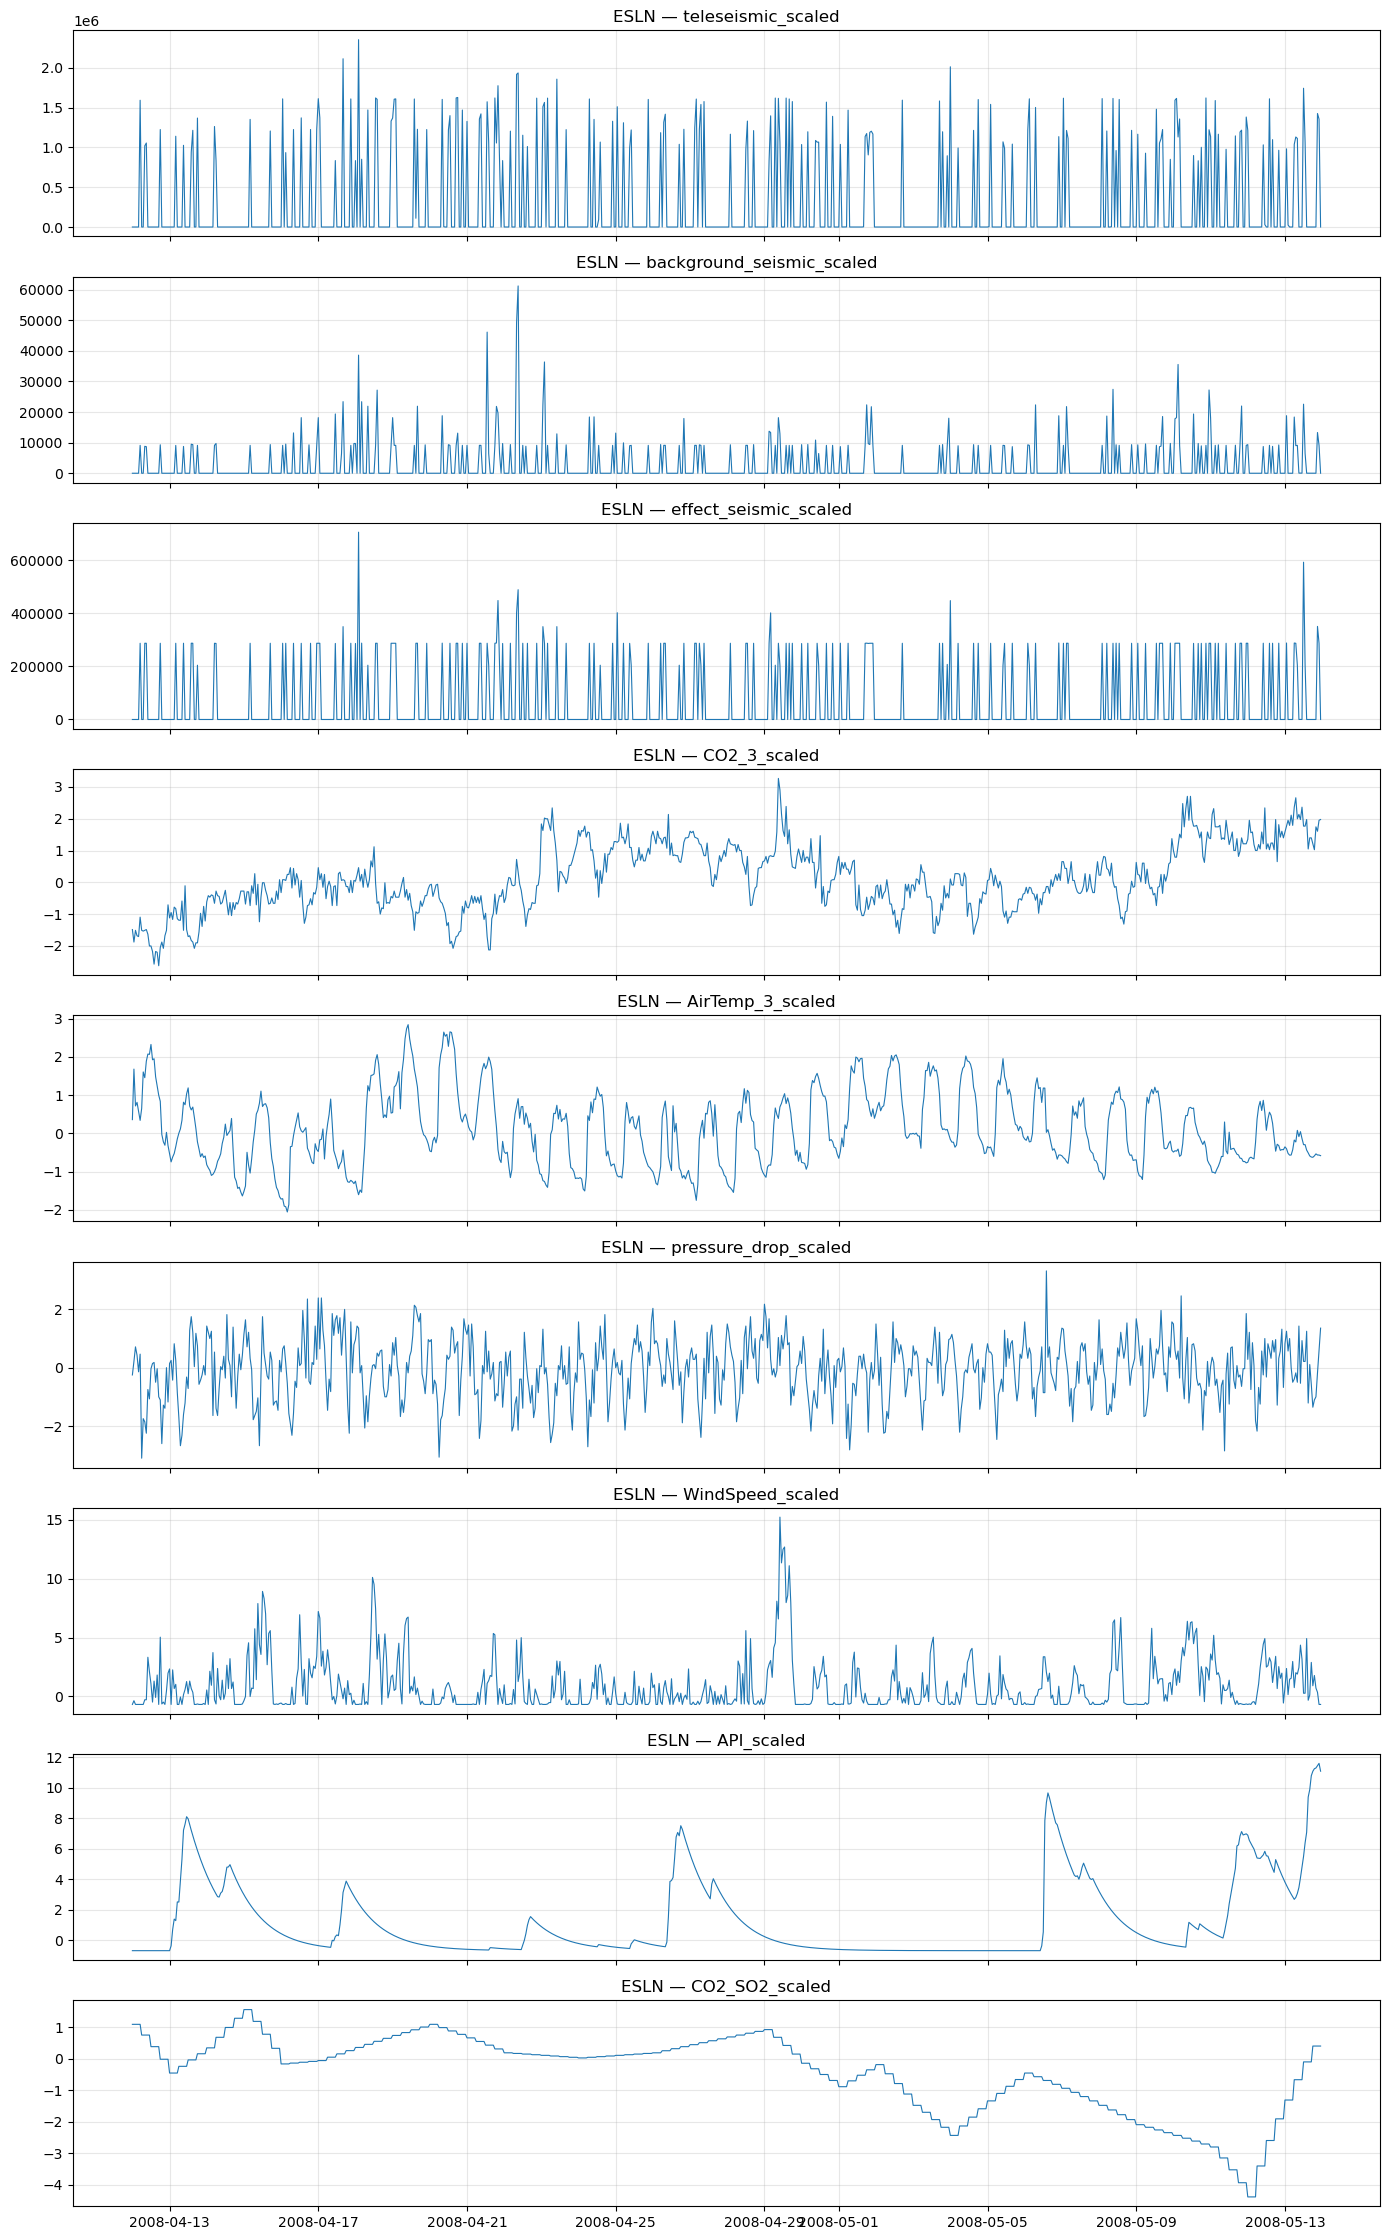

In [12]:
for sta, d in station_data.items():
    plot_scaled_dataset(d["final_scaled"], sta)

## 7. Distribution diagnostics

Empirical density plots and summary statistics are used to inspect skewness, outliers, and scaling behavior. 

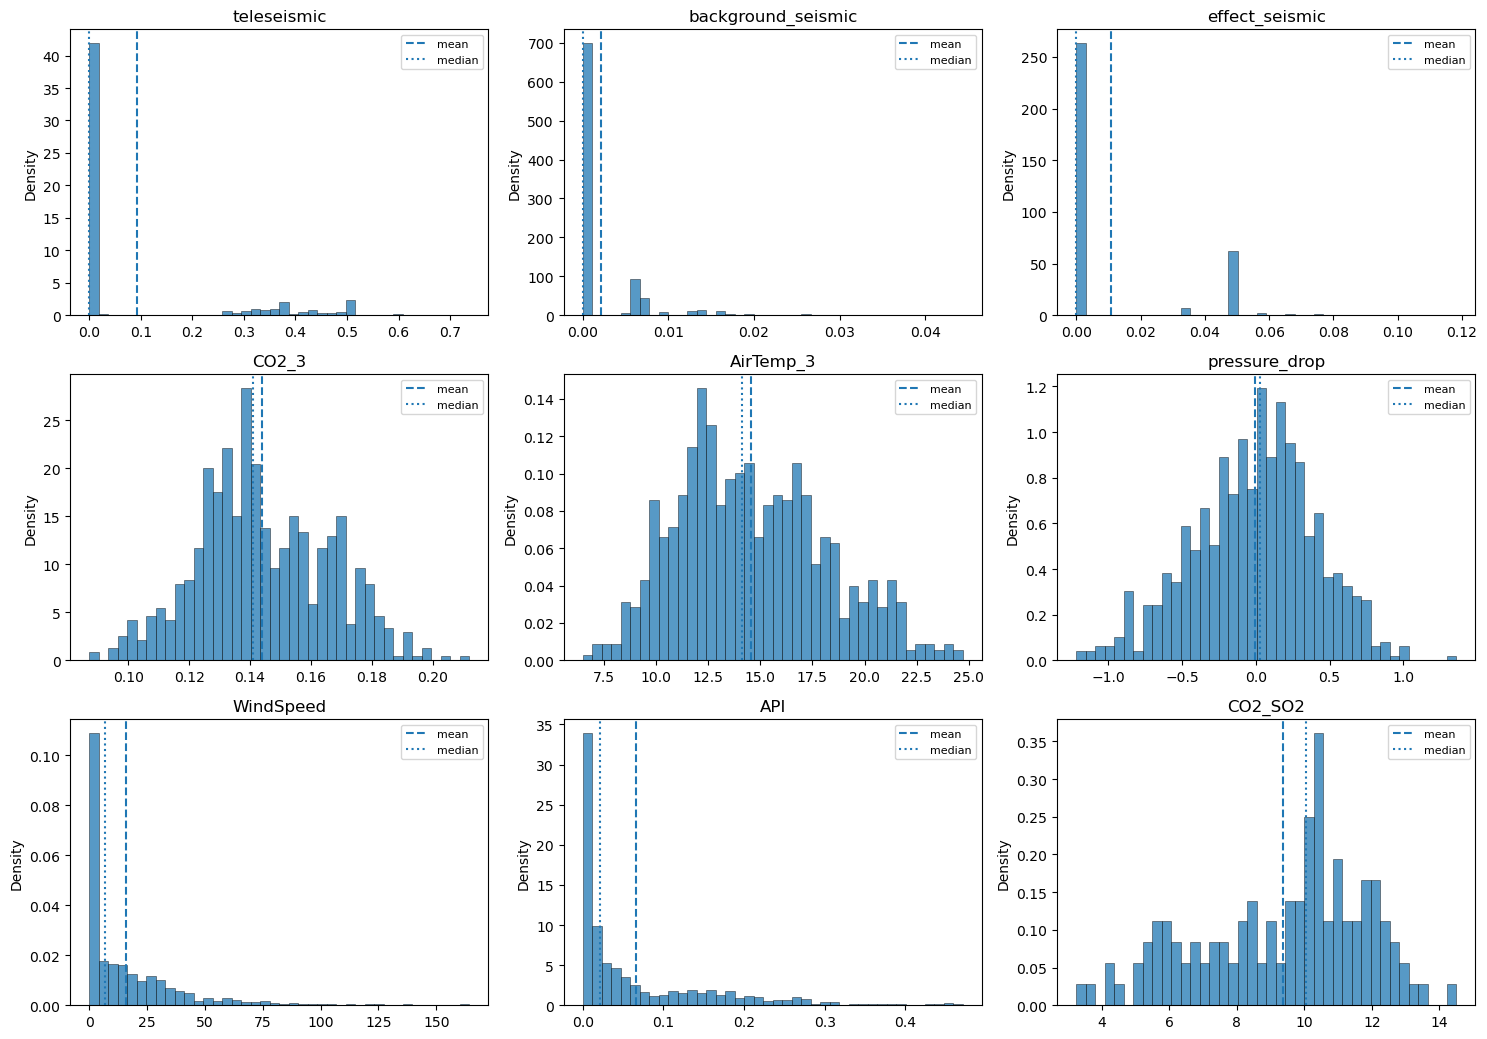

In [13]:
plot_variable_pdfs(final_esln_raw, filename="etna_esln_pdf.png")

#### distribution summary table

In [14]:
summary_esln = distribution_summary(final_esln_raw)
display(summary_esln)


,count,mean,std,min,median,max,skew,n_unique,missing_fraction
API,768.0,0.065748,0.090627,0.000000e+00,2.152954e-02,0.471235,1.813461,744,0.0
AirTemp_3,768.0,14.584061,3.554884,6.505817e+00,1.413981e+01,24.711043,0.385937,653,0.0
CO2_3,768.0,0.144006,0.021489,8.714800e-02,1.410860e-01,0.212085,0.180726,164,0.0
CO2_SO2,768.0,9.366797,2.453493,3.250000e+00,1.005000e+01,14.500000,-0.475693,108,0.0
WindSpeed,768.0,16.040706,22.366606,0.000000e+00,6.967213e+00,164.344262,2.271767,161,0.0
background_seismic,768.0,0.002086,0.004730,3.393319e-16,1.057110e-06,0.044378,3.435345,768,0.0
effect_seismic,768.0,0.010763,0.020668,1.385237e-07,3.510798e-07,0.118221,1.579256,768,0.0
pressure_drop,768.0,-0.005308,0.411382,-1.215906e+00,2.861000e-02,1.358955,-0.211724,284,0.0
teleseismic,768.0,0.091802,0.175773,7.554136e-08,3.148007e-07,0.737661,1.537714,768,0.0


## 8. Teleseismic arrival diagnostics

We inspect the waveform around the Wenchuan earthquake arrival. The 1-minute RMS is compared with hourly maximum aggregation to verify that the hourly grid preserves the arrival-period energy. The spectrogram confirms that the selected frequency bands capture the relevant trigger and response components.

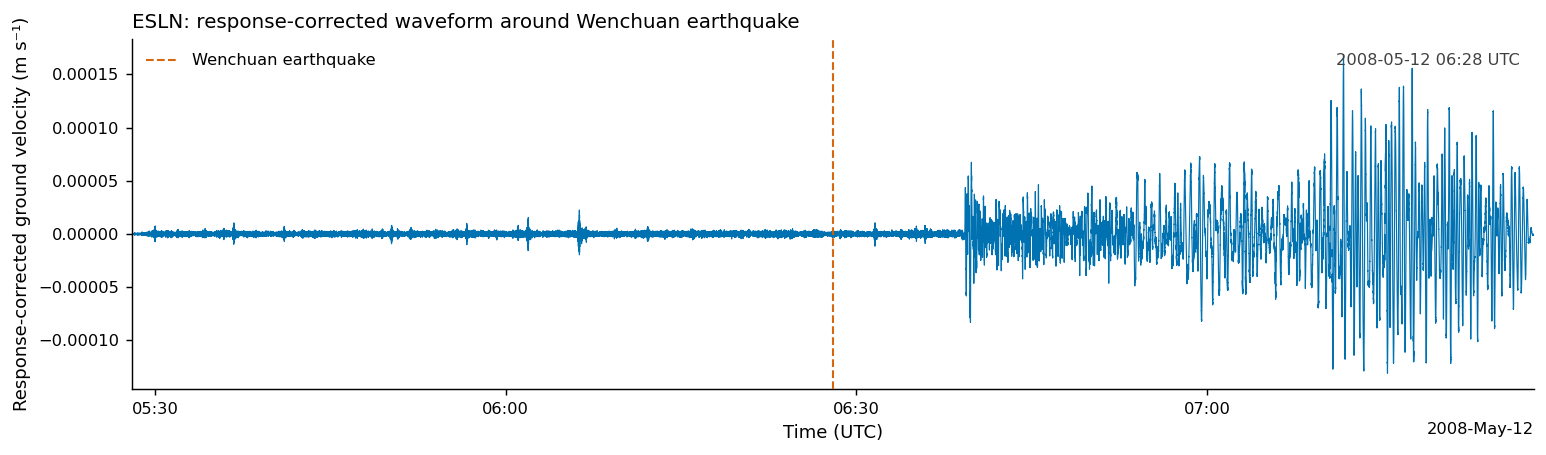

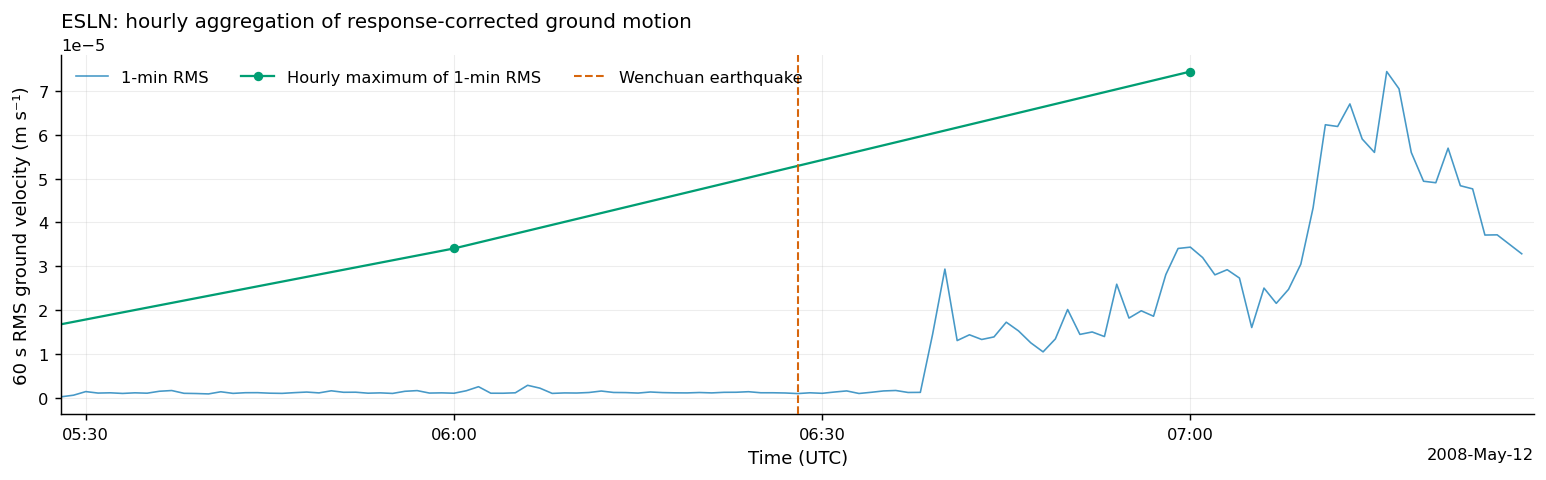


ESLN
1-min peak: 2008-05-12 07:16:00+00:00
hourly peak bin: 2008-05-12 07:00:00+00:00
difference: 0 days 00:16:00


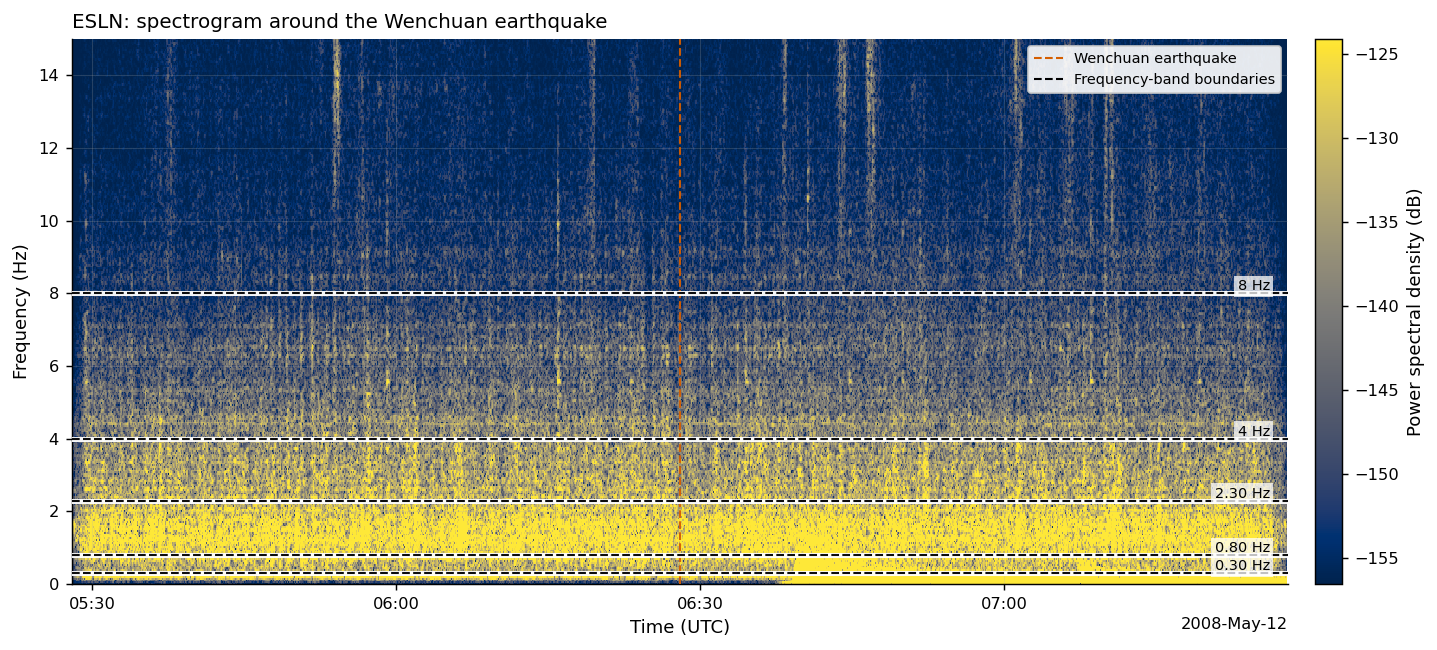

c:\Users\cescedes\Desktop\Distinguishing Causes and Triggers in Volcanic and Seismic Processes\src\etna\etna_plotting_utils.py:534: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


In [15]:
results = {}

results[ETNA_STATION] = run_teleseismic_checks(
    client=client,
    station=ETNA_STATION,
    cfg=ETNA_WAVEFORM_CONFIG,
    event_time=ETNA_EVENT_TIME,
)


## 9. Final hourly dataset with event marker

The final dataset is plotted with the teleseismic event time marked. This provides a visual check that the causal-analysis dataset aligns with the known event window.

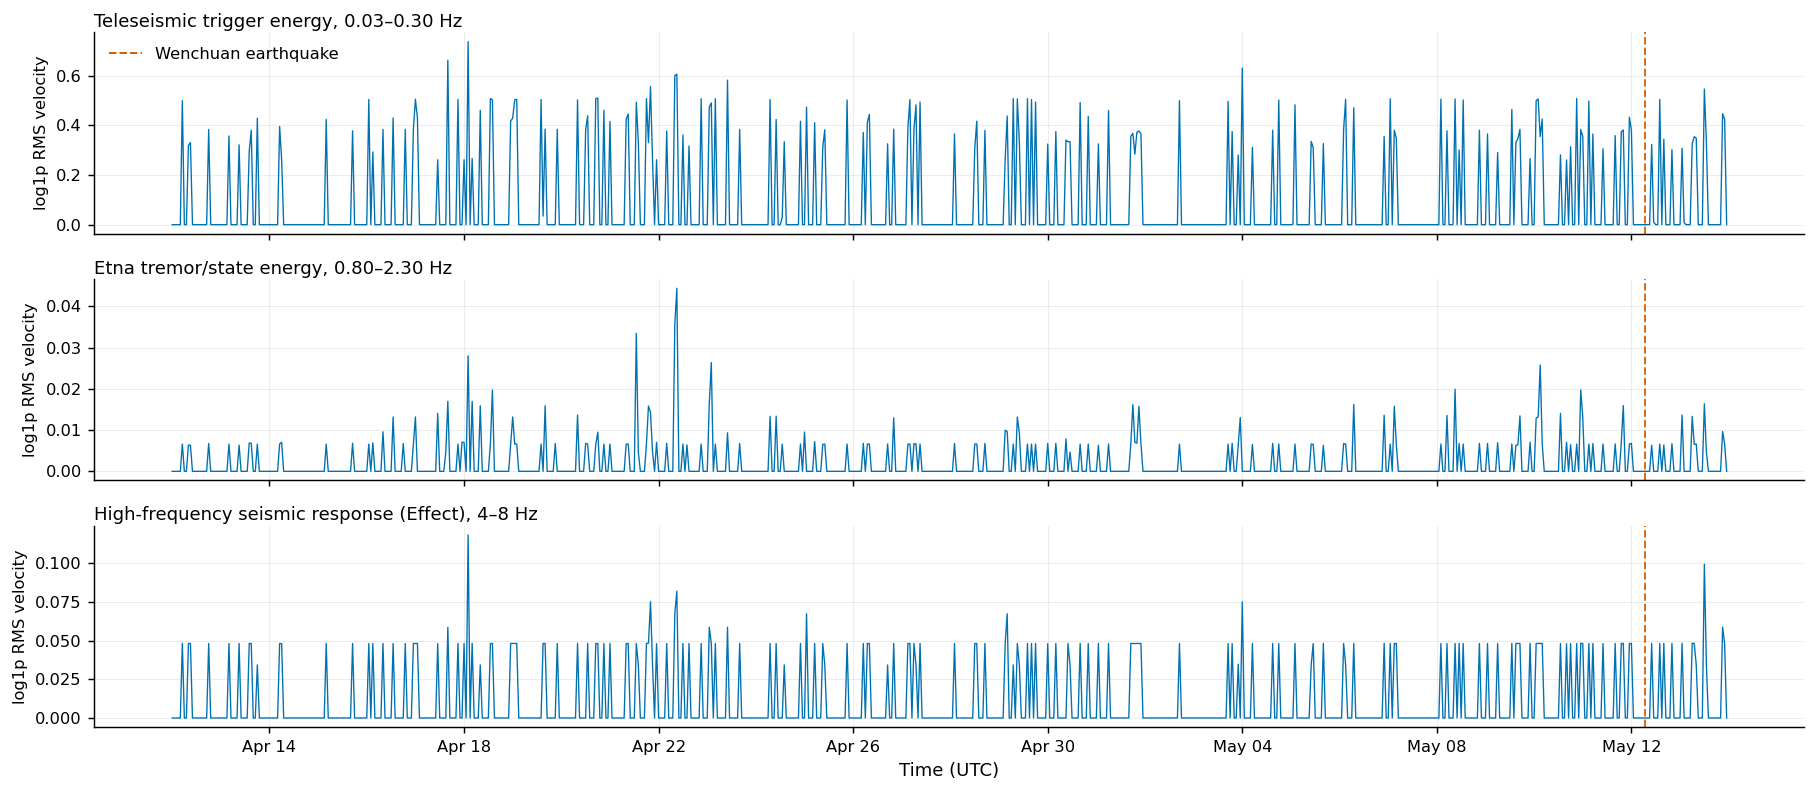

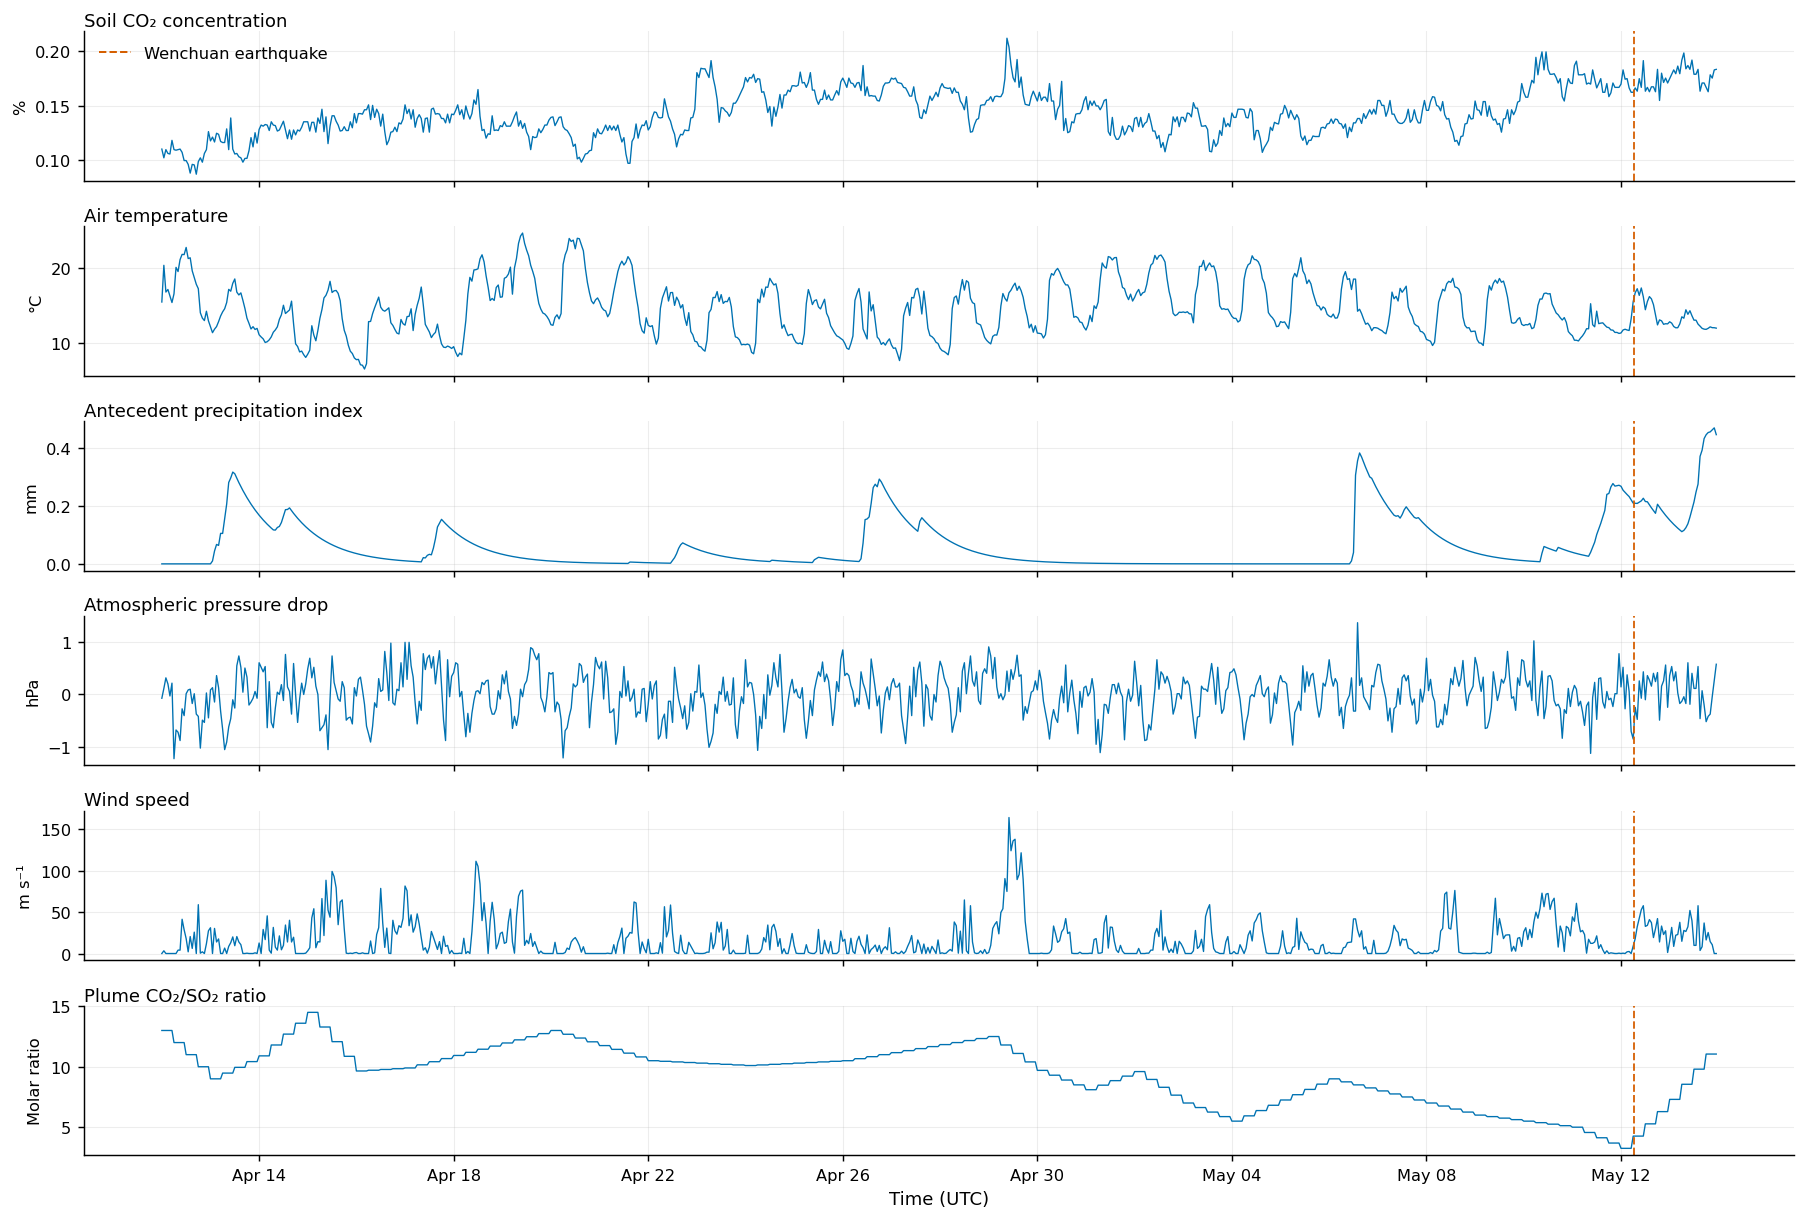

In [16]:
from etna_plotting_utils import ETNA_SEISMIC_COLS, ETNA_EXTERNAL_COLS

plot_etna_data_with_event(
    "../data/etna/FINAL_ESLN_raw.csv",
    station=ETNA_STATION,
    event_time=ETNA_EVENT_TIME,
    cols=ETNA_SEISMIC_COLS,
    figsize=(14, 6.2),
    filename="etna_esln_seismic_variables",
)

plot_etna_data_with_event(
    "../data/etna/FINAL_ESLN_raw.csv",
    station=ETNA_STATION,
    event_time=ETNA_EVENT_TIME,
    cols=ETNA_EXTERNAL_COLS,
    figsize=(14, 9.5),
    filename="etna_esln_external_variables",
)


## 10. Geographic Visualization

,Source,Source ID,Variables
0,ESLN,ESLN,"background_seismic, effect_seismic, teleseismic"
1,"ETNAGAS network, 3c",ETNAGAS_3,"AirTemp_3, CO2_3, WindSpeed, pressure_drop"
2,"INGV-PA, Multi-GAS",ETNA_SUMMIT_PLUME,CO2_SO2
3,Open-Meteo,ETNA_OPENMETEO_PROXY,API


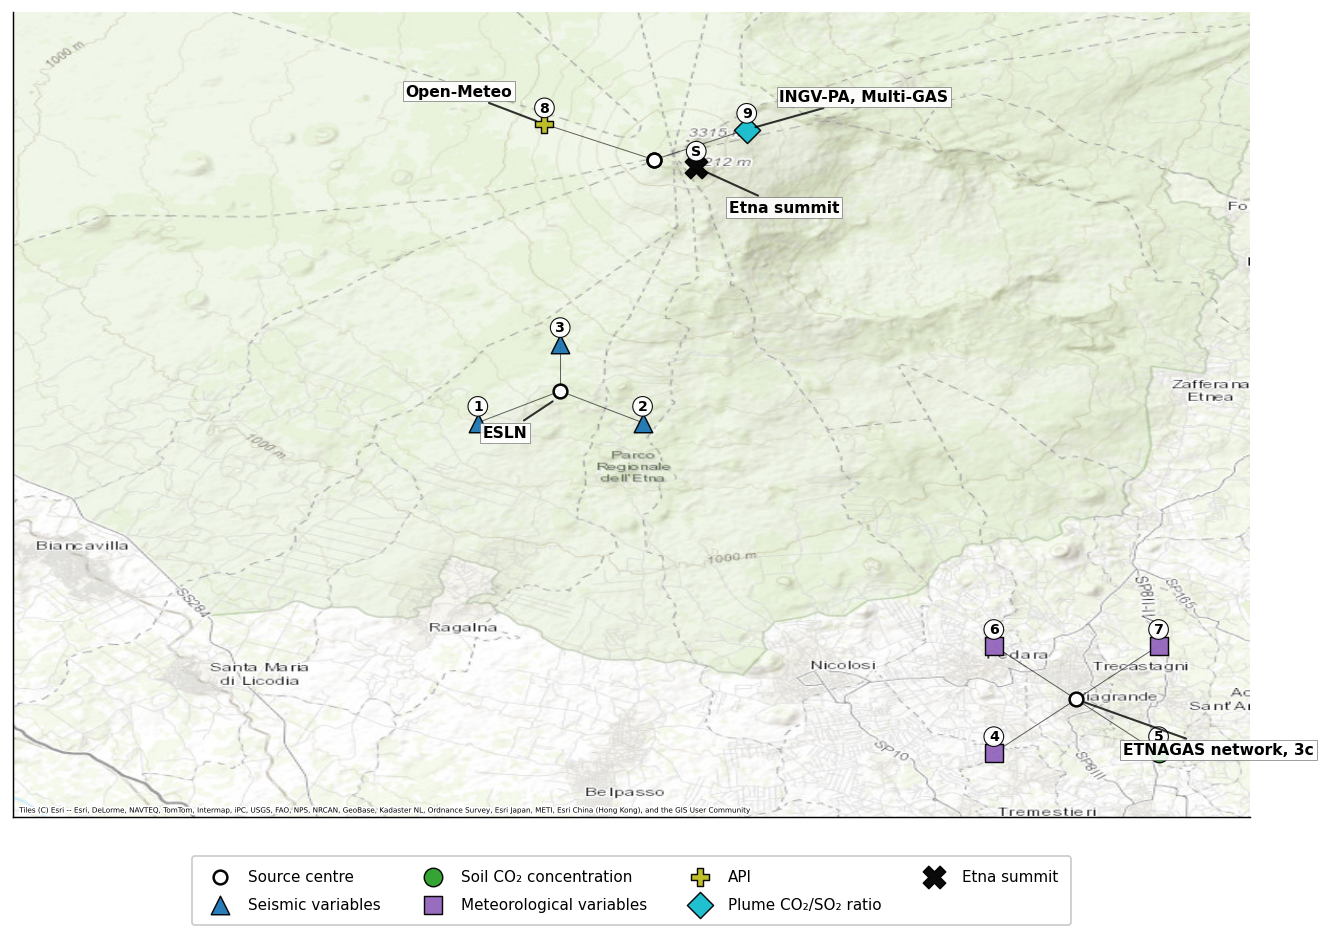

In [17]:
etna_meta = etna_observable_metadata()

fig, ax, etna_variable_table = plot_etna_all_variables_map(
    etna_meta,
    satellite=False,
    title=None,
    offset_radius_m=2300,
    filename="etna_map.png",
)

etna_variable_table

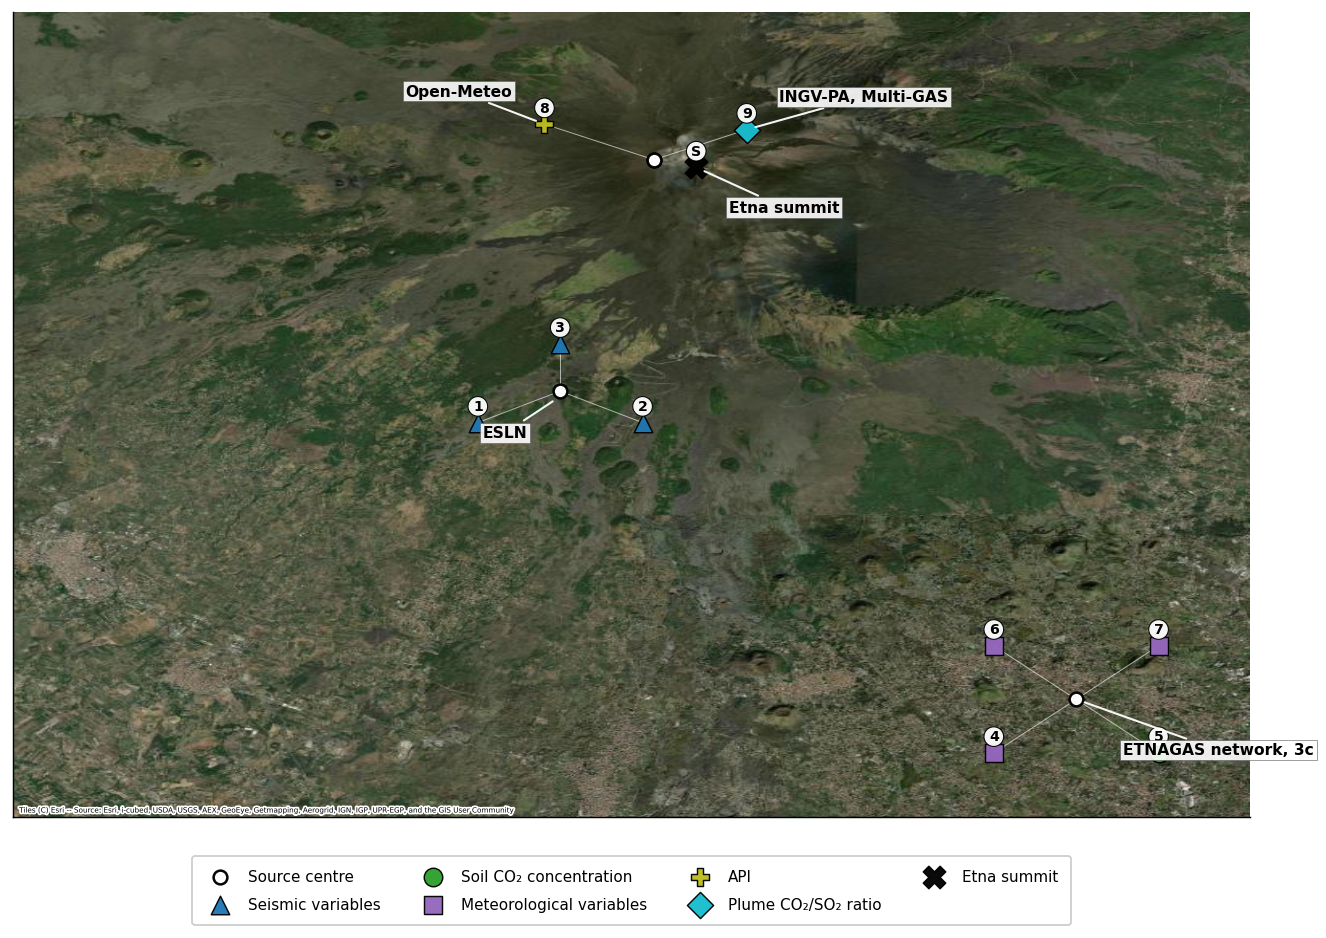

In [18]:
fig, ax, etna_variable_table = plot_etna_all_variables_map(
    etna_meta,
    satellite=True,
    title=None,
    offset_radius_m=2300,
    filename="etna_satellite.png",
)